# Diamond Price Prediction Using Machine Learning Regression

## Problem Statement
> Predict the price of a diamond using its measurable characteristics such as carat, cut, color, clarity, depth, table, and physical dimensions.

### Project Overview & Identification:
- **Target Variable ($y$):** `price` (Continuous price in USD, ranging from $326 to $18,823)
- **Dataset Source:** UCI / StatLib Diamonds Dataset (`datasets/diamonds.csv`)
- **Regression Problem:** Diamond characteristics $\longrightarrow$ Predicted diamond price
- **Objective:** Build a robust, leakage-free machine learning regression pipeline supporting 10 standard algorithms, comparing their predictive accuracy ($R^2$, RMSE, MAE), tuning hyperparameters, and validating findings.

## Milestone 1: Dataset Loading & Audit

In this first milestone, we:
1. Ingest the official `datasets/diamonds.csv` dataset.
2. Inspect the first and last records to verify column alignment.
3. Conduct a comprehensive structural audit (shape, data types, missing values, duplicate rows, cardinality).
4. Perform an initial audit of the target variable `price` (descriptive statistics, quartiles, skewness, and visual distribution).
5. Define the feature catalog separating numerical and categorical predictors.

*Note: In accordance with the sequential milestone plan, no cleaning, outlier removal, transformations, or modeling are executed in this commit.*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics for clean, publication-ready figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 110

print("Environment and libraries initialized successfully.")

Environment and libraries initialized successfully.


### 1. Load the Dataset
Loading `datasets/diamonds.csv` without modifying the original data file. Relative paths ensure reproducibility regardless of working directory.

In [2]:
# Resolve dataset path portably
data_path = os.path.join("..", "datasets", "diamonds.csv") if os.path.exists(os.path.join("..", "datasets", "diamonds.csv")) else os.path.join("datasets", "diamonds.csv")
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded from: {data_path}")
print(f"Exact Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset successfully loaded from: ..\datasets\diamonds.csv
Exact Shape: 53,940 rows x 10 columns


### 2. Initial Sample Inspection
Displaying the first 5 rows and last 5 rows of the dataset.

In [3]:
print("First 5 rows of the dataset:")
display(df.head())

print()
print("Last 5 rows of the dataset:")
display(df.tail())

First 5 rows of the dataset:


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335



Last 5 rows of the dataset:


,carat,cut,color,clarity,depth,table,x,y,z,price
53935,0.72,Ideal,D,SI1,60.8,57.0,5.75,5.76,3.50,2757
53936,0.72,Good,D,SI1,63.1,55.0,5.69,5.75,3.61,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,5.66,5.68,3.56,2757
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757
53939,0.75,Ideal,D,SI2,62.2,55.0,5.83,5.87,3.64,2757


### 3. Comprehensive Dataset Audit
Auditing column names, data types, null/missing counts, missing percentages, and unique value counts in a structured summary table.

In [4]:
# Dataset audit table
audit_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Count': df.nunique()
}).reset_index(drop=True)

display(audit_df)

# Duplicate row check
dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100
print()
print(f"Exact Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

,Column Name,Data Type,Missing Count,Missing (%),Unique Count
0,carat,float64,0,0.0,273
1,cut,str,0,0.0,5
2,color,str,0,0.0,7
3,clarity,str,0,0.0,8
4,depth,float64,0,0.0,184
5,table,float64,0,0.0,127
6,x,float64,0,0.0,554
7,y,float64,0,0.0,552
8,z,float64,0,0.0,375
9,price,int64,0,0.0,11602



Exact Duplicate Rows: 146 (0.27% of dataset)


### 4. Target Variable (`price`) Audit
Auditing descriptive statistics, quartiles, interquartile range (IQR), and skewness for the continuous target `price`.

In [5]:
price = df['price']

target_summary = pd.DataFrame({
    'Metric': [
        'Total Count', 'Minimum Price', 'Maximum Price', 'Mean Price', 
        'Median Price', 'Standard Deviation', 'Q1 (25th percentile)', 
        'Q3 (75th percentile)', 'IQR (Interquartile Range)', 
        'Skewness', 'Kurtosis', 'Unique Target Values'
    ],
    'Value': [
        f"{len(price):,}",
        f"${price.min():,}",
        f"${price.max():,}",
        f"${price.mean():,.2f}",
        f"${price.median():,.2f}",
        f"${price.std():,.2f}",
        f"${price.quantile(0.25):,.2f}",
        f"${price.quantile(0.75):,.2f}",
        f"${(price.quantile(0.75) - price.quantile(0.25)):,.2f}",
        f"{price.skew():.4f}",
        f"{price.kurtosis():.4f}",
        f"{price.nunique():,}"
    ]
})

display(target_summary)

,Metric,Value
0,Total Count,"53,940"
1,Minimum Price,$326
2,Maximum Price,"$18,823"
3,Mean Price,"$3,932.80"
4,Median Price,"$2,401.00"
5,Standard Deviation,"$3,989.44"
6,Q1 (25th percentile),$950.00
7,Q3 (75th percentile),"$5,324.25"
8,IQR (Interquartile Range),"$4,374.25"
9,Skewness,1.6184


### 5. Target Distribution Visualization
Generating the baseline distribution plot for `price` with KDE and statistical reference lines.

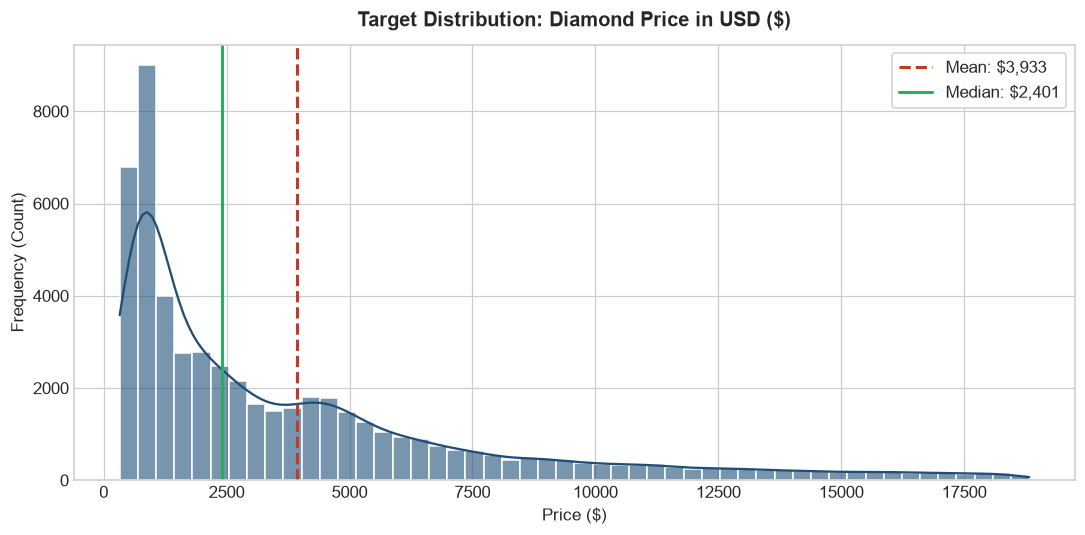

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['price'], bins=50, kde=True, color='#1f4e79', edgecolor='white', alpha=0.6, ax=ax)

# Reference vertical lines for Mean and Median
ax.axvline(price.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f"Mean: ${price.mean():,.0f}")
ax.axvline(price.median(), color='#27ae60', linestyle='-', linewidth=2, label=f"Median: ${price.median():,.0f}")

ax.set_title("Target Distribution: Diamond Price in USD ($)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Price ($)", fontsize=11)
ax.set_ylabel("Frequency (Count)", fontsize=11)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

#### Target Distribution Observation:
- **Severe Positive Skewness:** The raw price distribution displays strong right-skewness ($\text{Skewness} = +1.6184$), with a mean of $\$3,932.80$ pulled above the median of $\$2,401.00$.
- **High-Mass Concentration:** The bulk of diamonds ($> 50\%$) are concentrated in the $\$326 - \$2,500$ range, while rare, high-carat diamonds form a long right tail up to $\$18,823$.
- **Modeling Implication:** Linear regression models minimizing Mean Squared Error (MSE) may be heavily influenced by errors on high-value diamonds in the tail; log-transformations and robust loss functions will be evaluated in subsequent milestones.

### 6. Feature Overview: Numerical & Categorical Attributes

| Feature Name | Type | Measurement Unit | Description & Gemological Role |
| :--- | :--- | :--- | :--- |
| **`carat`** | Numerical | Carats ($1\text{ ct} = 0.2\text{ g}$) | Physical weight/mass of the diamond; primary exponential driver of price. |
| **`depth`** | Numerical | Percentage ($\%$) | Total depth percentage: $2z / (x + y) \times 100$. Relates height to diameter. |
| **`table`** | Numerical | Percentage ($\%$) | Width of the diamond's top facet relative to its widest point ($43 - 95\%$). |
| **`x`** | Numerical | Millimeters (mm) | Length of the diamond ($0.00 - 10.74\text{ mm}$). |
| **`y`** | Numerical | Millimeters (mm) | Width of the diamond ($0.00 - 58.90\text{ mm}$). |
| **`z`** | Numerical | Millimeters (mm) | Depth/height of the diamond ($0.00 - 31.80\text{ mm}$). |
| **`cut`** | Categorical | Ordinal Grade | Cut quality: `Fair` < `Good` < `Very Good` < `Premium` < `Ideal`. Affects brilliance. |
| **`color`** | Categorical | Ordinal Grade | Color grading: `J` (worst / faint yellow) to `D` (best / colorless). |
| **`clarity`** | Categorical | Ordinal Grade | Clarity grading: `I1` (worst) to `IF` (best, internally flawless). |

## Commit 1 Summary

| Audit Item | Value | Initial Observation |
| :--- | :--- | :--- |
| **Dataset Dimensions** | 53,940 rows $\times$ 10 columns | Substantial sample size accommodating all 10 regression algorithms |
| **Predictor Count** | 9 features (6 numerical, 3 categorical) | Matches optimal 7–10 feature window for interpretable regression |
| **Target Variable** | `price` (continuous integer) | 11,602 unique price levels; right-skewed (\$326 to \$18,823) |
| **Missing Values** | **0 missing values (0.00%)** | Tabular completeness across all 10 columns |
| **Duplicate Rows** | **146 rows (0.27%)** | Exact duplicates identified for treatment in the cleaning milestone |
| **Initial Observation** | Physical dimensions | Zero-value dimensions ($x, y, z = 0$) and dimensional typos flagged for cleaning |